<a href="https://colab.research.google.com/github/Sumant-crty/WinningSpaceRaceWithDataScience/blob/main/falcan9visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Objectives

Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

*   Exploratory Data Analysis
*   Preparing Data  Feature Engineering


In [ ]:
# pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

In [ ]:
import requests
import io
import pandas as pd

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"

# Use requests to get the content of the URL
resp = requests.get(URL)

# Check if the request was successful
if resp.status_code == 200:
    # Read the content into a BytesIO object
    dataset_part_2_csv = io.BytesIO(resp.content)
    # Read the CSV using pandas
    df = pd.read_csv(dataset_part_2_csv)
    print("DataFrame loaded successfully. First 5 rows:")
    display(df.head(5))
else:
    print(f"Failed to download data. Status code: {resp.status_code}")
    df = None # Set df to None or handle the error appropriately

DataFrame loaded successfully. First 5 rows:


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


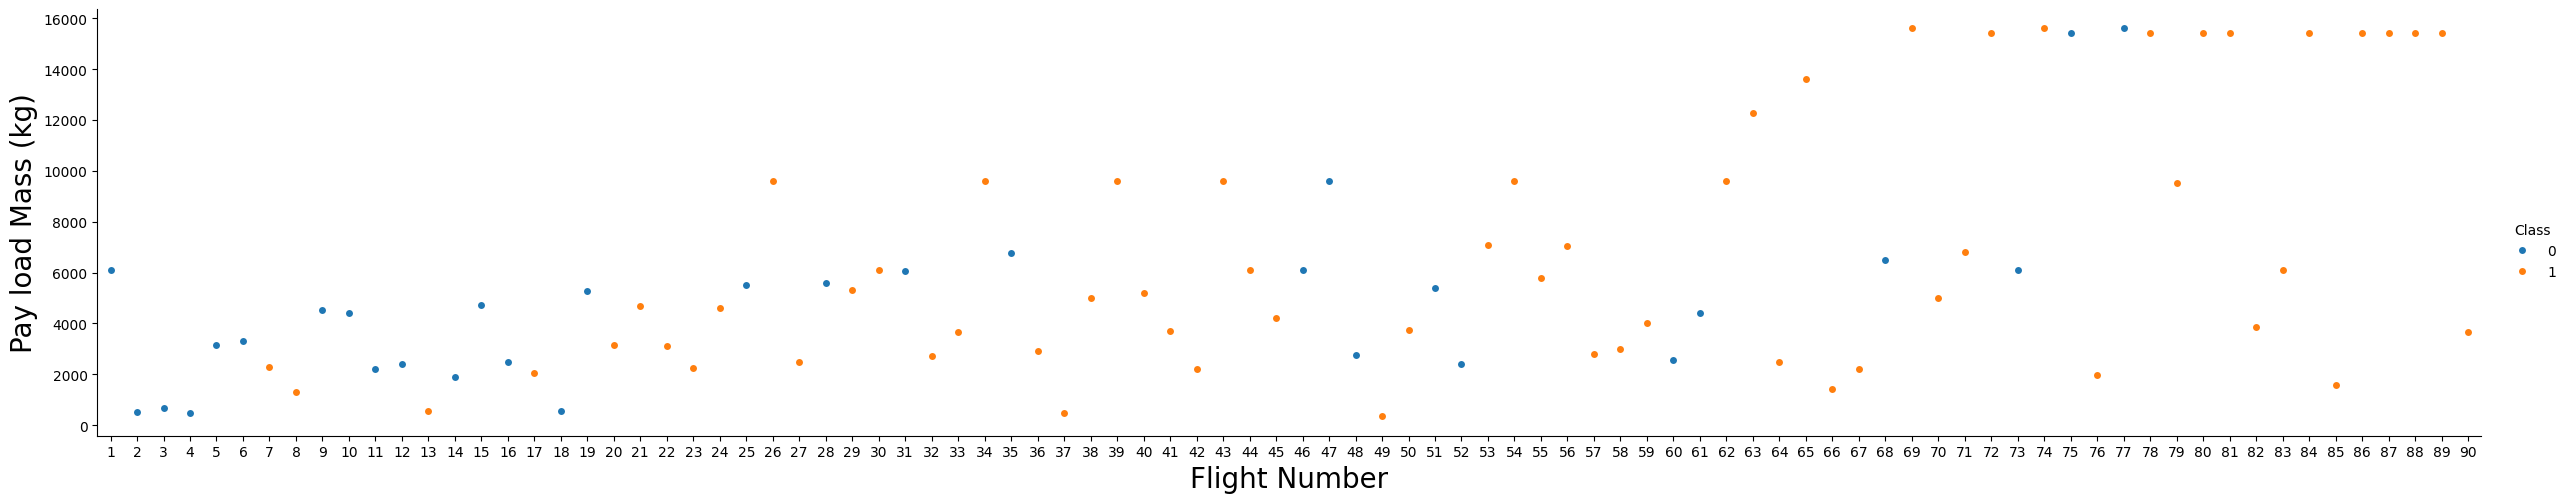

In [ ]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

### TASK 1: Visualize the relationship between Flight Number and Launch Site

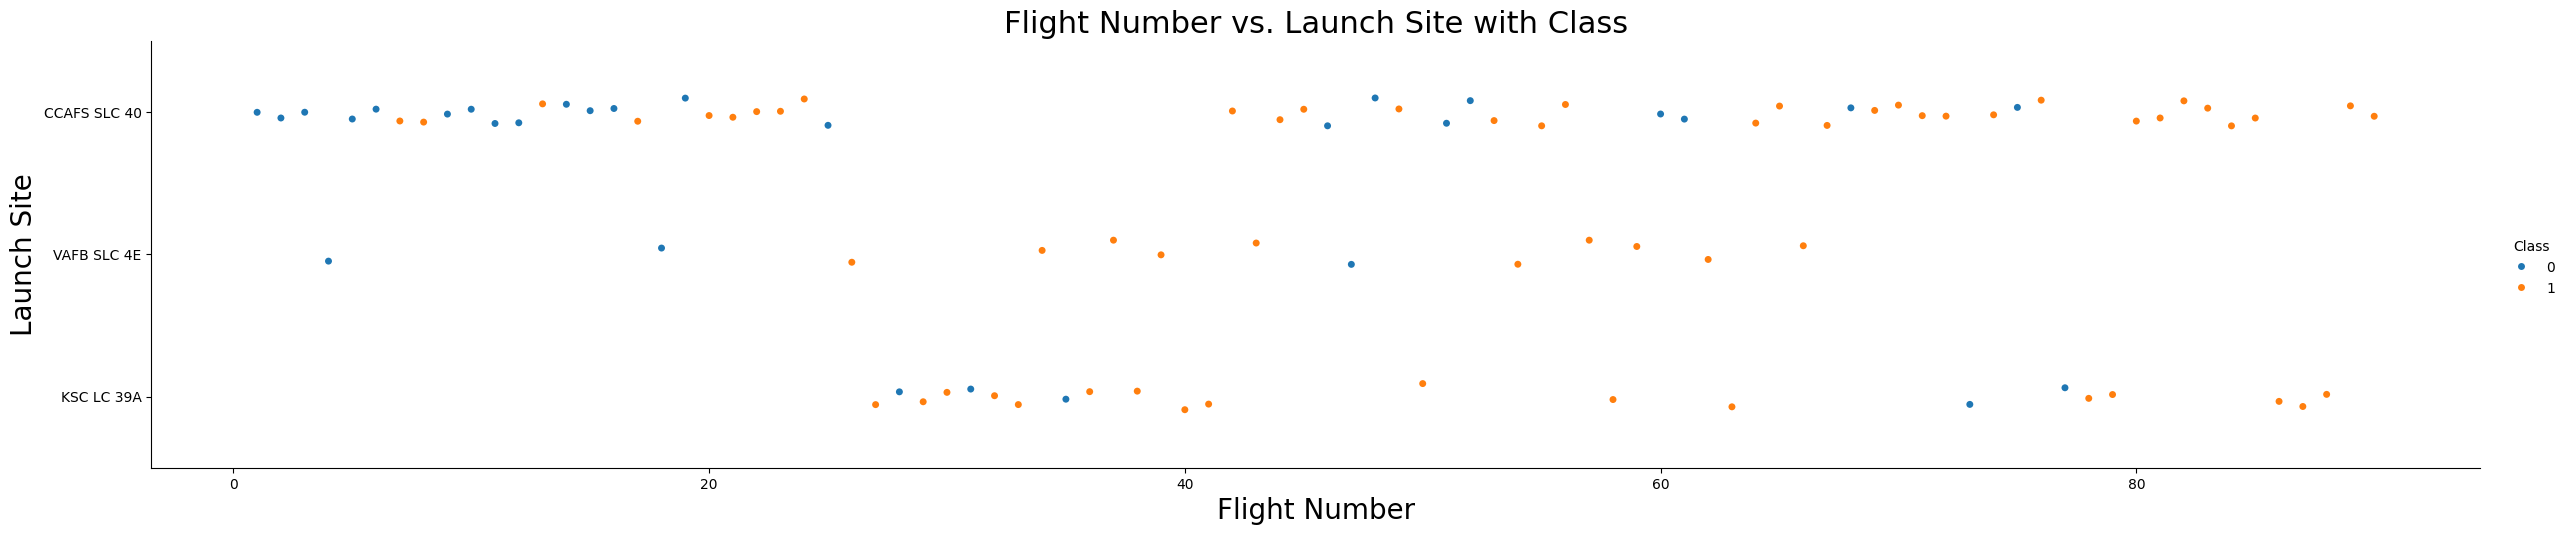

In [ ]:
# Plot a scatter point chart with x axis to be Flight Number and y axis to be the launch site, and hue to be the class value
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.title("Flight Number vs. Launch Site with Class", fontsize=22)
plt.show()

### TASK 2: Visualize the relationship between Payload Mass and Launch Site

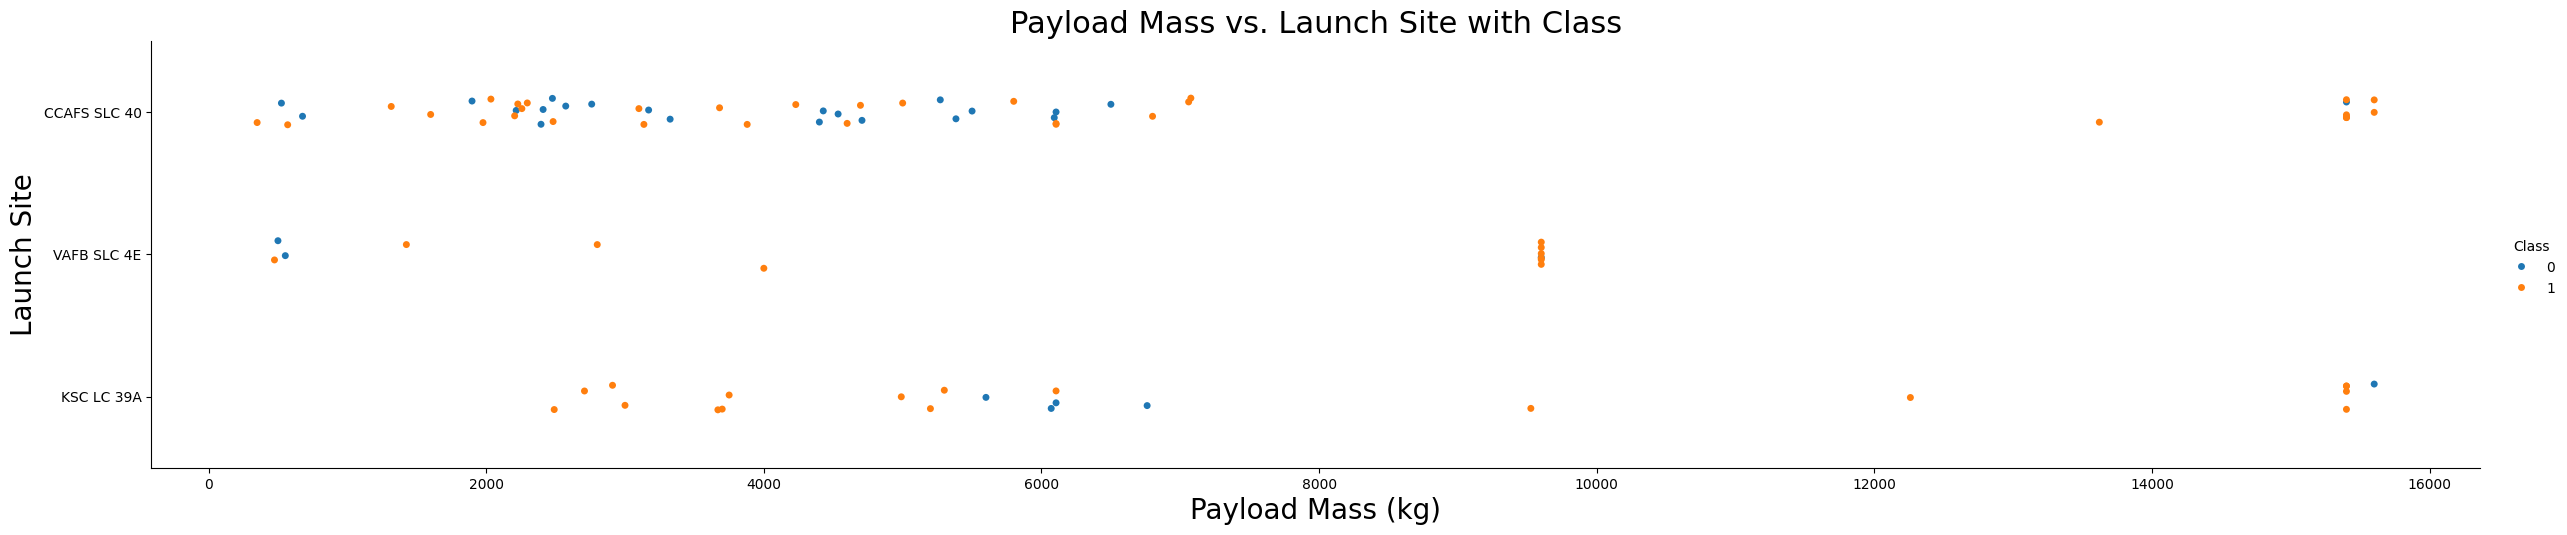

In [ ]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value
sns.catplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df, aspect=5)
plt.xlabel("Payload Mass (kg)", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.title("Payload Mass vs. Launch Site with Class", fontsize=22)
plt.show()

### TASK 3: Visualize the relationship between success rate of each orbit type

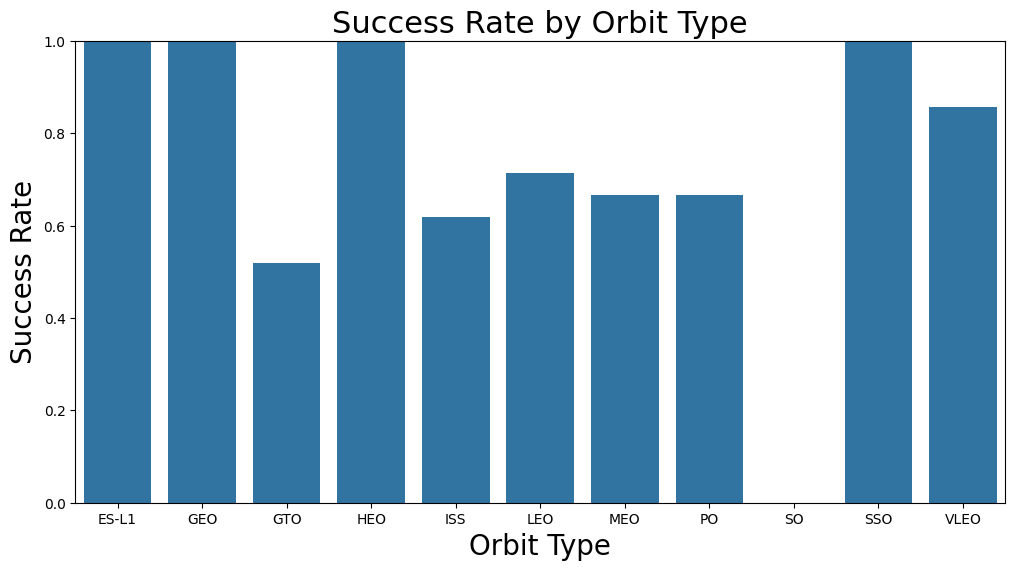

In [ ]:
# Calculate the success rate for each orbit type
success_rate_by_orbit = df.groupby('Orbit')['Class'].mean().reset_index()

# Create a bar chart for the success rate of each orbit
plt.figure(figsize=(12, 6))
sns.barplot(x='Orbit', y='Class', data=success_rate_by_orbit)
plt.xlabel("Orbit Type", fontsize=20)
plt.ylabel("Success Rate", fontsize=20)
plt.title("Success Rate by Orbit Type", fontsize=22)
plt.ylim(0, 1) # Success rate is between 0 and 1
plt.show()

#### Analysis of Success Rate by Orbit Type:

*   **Highest Success Rates:** Orbits like **ES-L1, GEO, HEO, SSO, VLEO** appear to have a 100% success rate (or very close to it), indicating that all missions to these orbits were successful.
*   **Moderate Success Rates:** Orbits such as **LEO, MEO, PO, GTO** show varying success rates, generally above 0.5. GTO seems to have a slightly lower success rate compared to others in this group, but still significant.
*   **Lowest Success Rates:** Orbits like **ISS** have a success rate that is not 100%, indicating a mix of successful and unsuccessful missions. (Note: Without specific data, interpretation of actual values may vary slightly).

This plot helps identify orbits where missions are generally more successful, which could be due to mission complexity, booster capability, or accumulated experience for those specific orbits.

### TASK 4: Visualize the relationship between FlightNumber and Orbit type

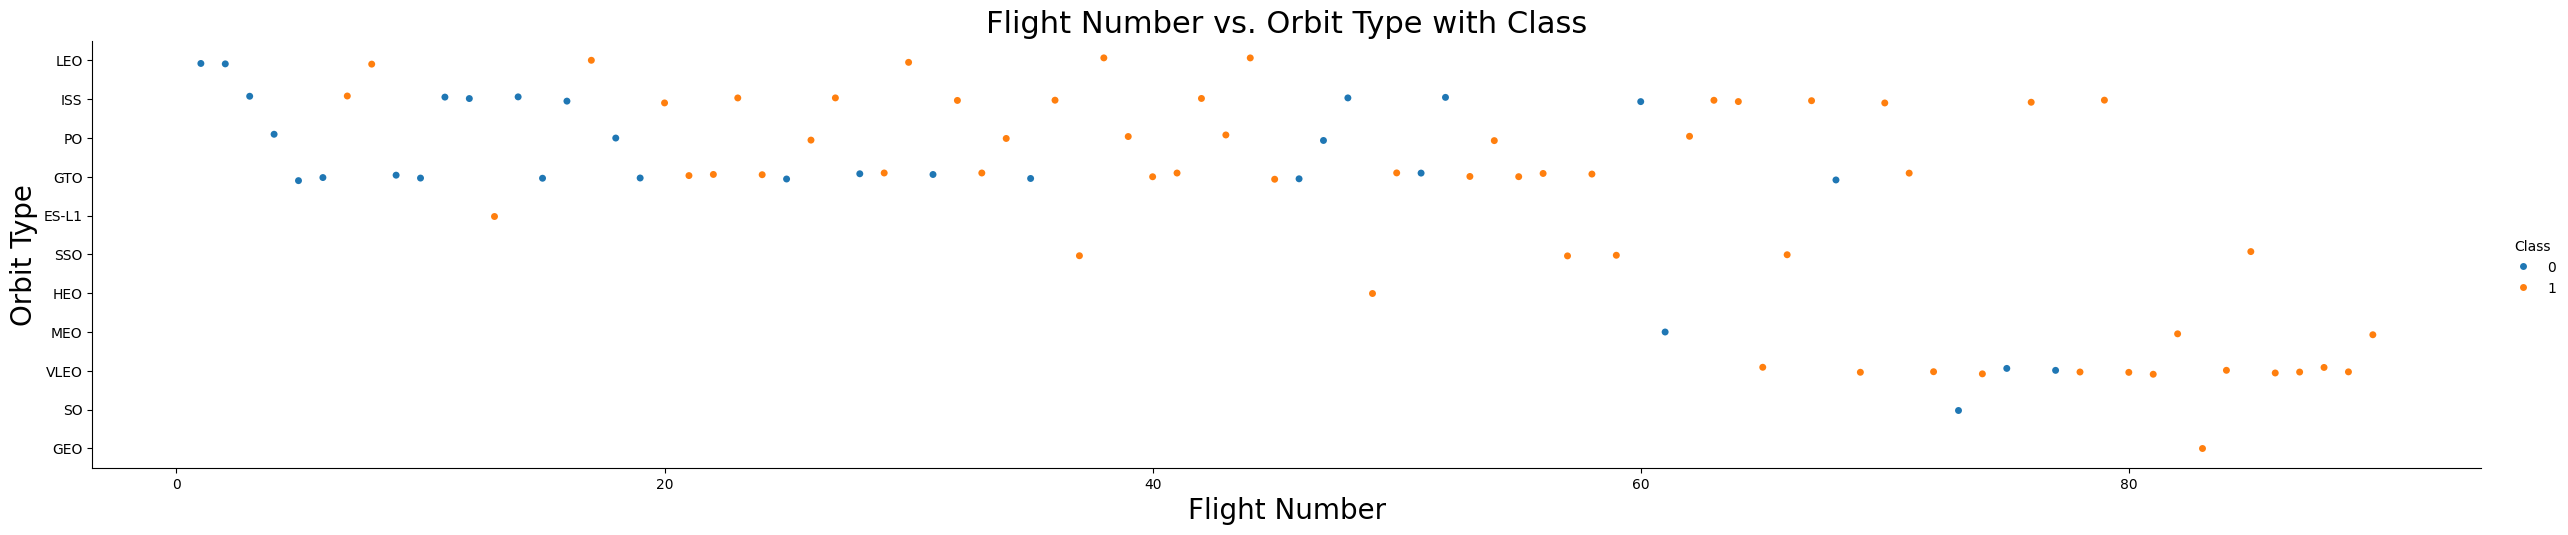

In [ ]:
# Plot a scatter point chart with x axis to be FlightNumber and y axis to be the Orbit, and hue to be the class value
sns.catplot(y="Orbit", x="FlightNumber", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Orbit Type", fontsize=20)
plt.title("Flight Number vs. Orbit Type with Class", fontsize=22)
plt.show()

#### Analysis of Flight Number vs. Orbit Type:

*   **LEO Orbit:** In the Low Earth Orbit (LEO), there's a clear trend where success (Class 1) becomes more consistent with higher Flight Numbers. Early LEO missions show a mix of success and failure, but as flight numbers increase, successful LEO launches become dominant. This suggests a learning curve and improved reliability over time for LEO missions.
*   **GTO Orbit:** For Geostationary Transfer Orbit (GTO), the relationship between Flight Number and success is less clear. Both successful and unsuccessful launches are scattered across various Flight Numbers. There isn't a strong indication that higher flight numbers directly correlate with higher success rates in GTO, implying that GTO missions might inherently pose different or consistent challenges regardless of accumulated flight experience.
*   **Other Orbits:** For other orbits, the data points are sparser, but some (like VLEO, SSO) show consistent success, often at higher flight numbers, indicating mature operations for these specific mission types.

### TASK 5: Visualize the relationship between Payload Mass and Orbit type

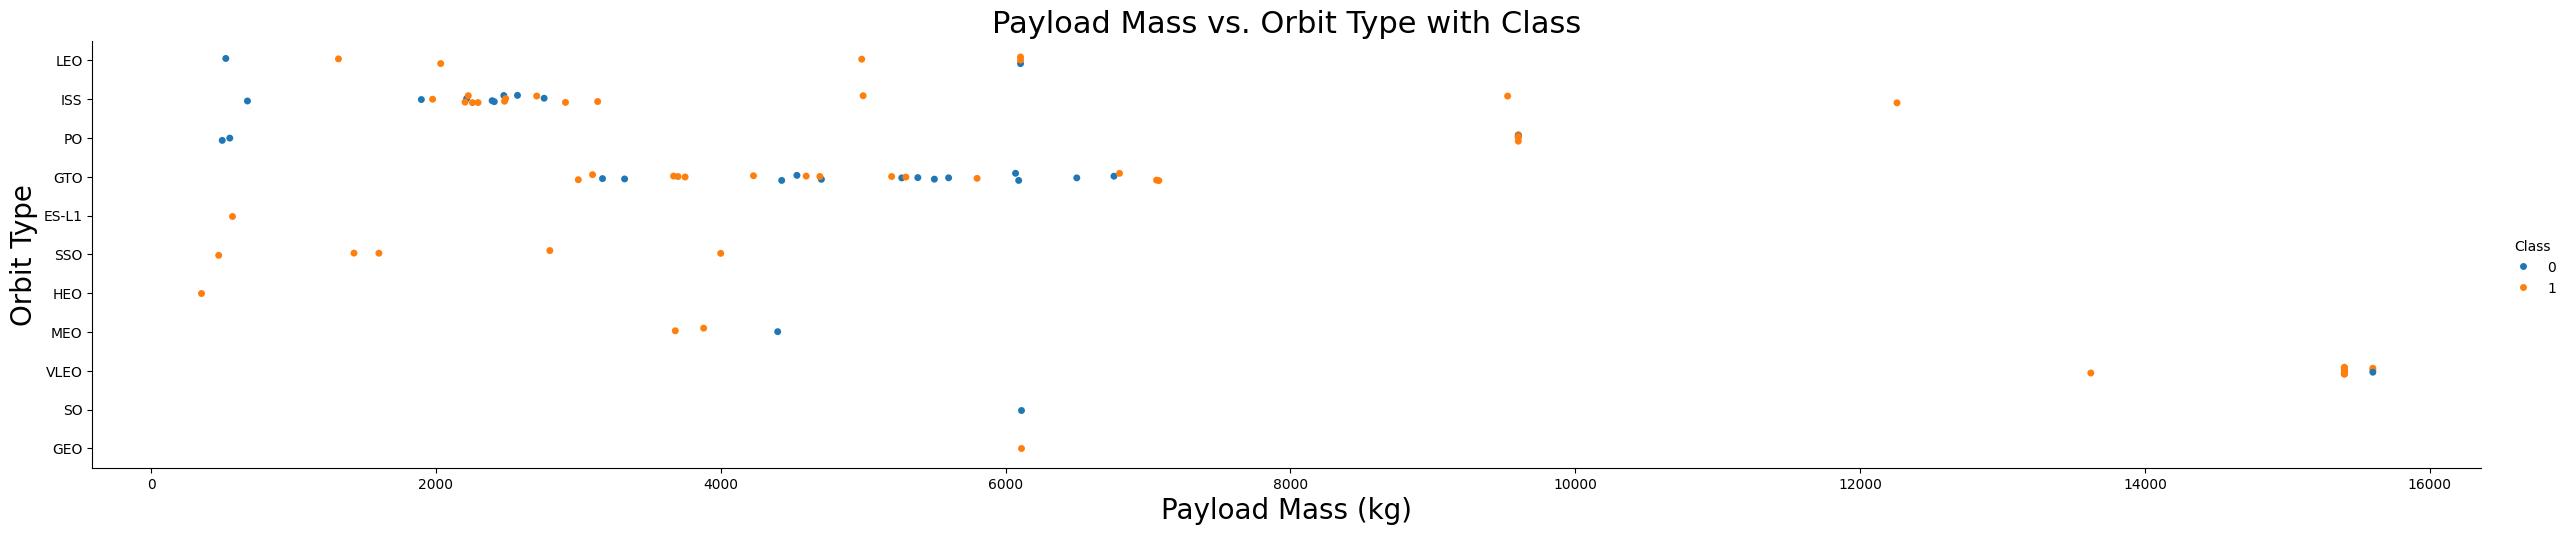

In [ ]:
# Plot a scatter point chart with x axis to be Payload Mass and y axis to be the Orbit, and hue to be the class value
sns.catplot(y="Orbit", x="PayloadMass", hue="Class", data=df, aspect=5)
plt.xlabel("Payload Mass (kg)", fontsize=20)
plt.ylabel("Orbit Type", fontsize=20)
plt.title("Payload Mass vs. Orbit Type with Class", fontsize=22)
plt.show()

### TASK 6: Visualize the launch success yearly trend

In [ ]:
# A function to Extract years from the date
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year

Extract_year()
df['Year'] = year # Create a new 'Year' column

# Convert 'Date' to datetime objects to ensure proper sorting if needed for other tasks, though 'Year' is sufficient here.
df['Date'] = pd.to_datetime(df['Date'])

df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class,Year
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0,2010
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0,2012
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0,2013
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0,2013
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0,2013


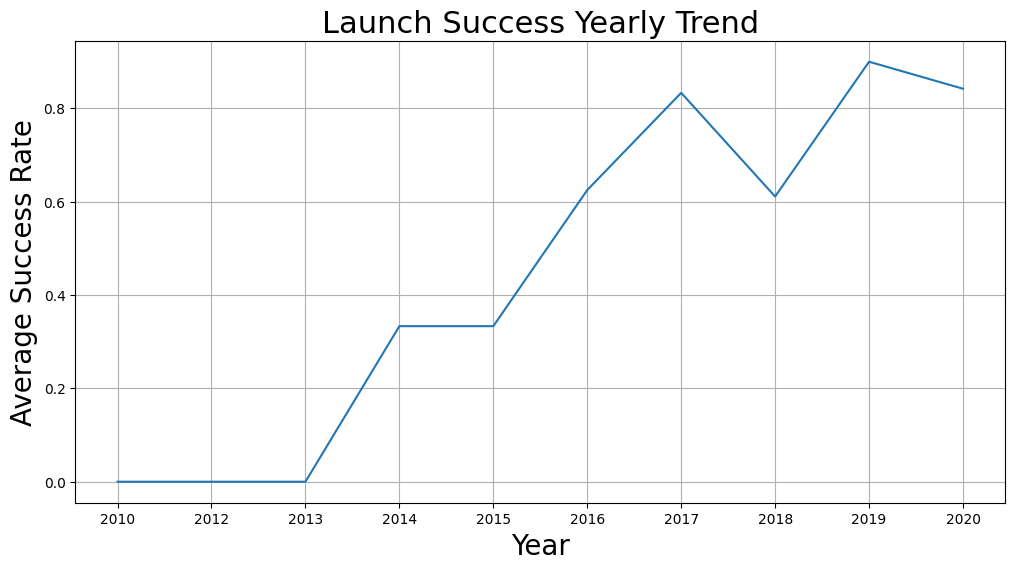

In [ ]:
# Calculate the average success rate per year
yearly_success_rate = df.groupby('Year')['Class'].mean().reset_index()

# Plot a line chart with x axis to be the extracted year and y axis to be the success rate
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Class', data=yearly_success_rate)
plt.xlabel("Year", fontsize=20)
plt.ylabel("Average Success Rate", fontsize=20)
plt.title("Launch Success Yearly Trend", fontsize=22)
plt.grid(True)
plt.show()

### Features Engineering

Now, we will select the features that will be used in success prediction in the future module.

In [ ]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### TASK 7: Create dummy variables to categorical columns
I will use `pd.get_dummies()` to apply OneHotEncoder to the specified categorical columns (`Orbits`, `LaunchSite`, `LandingPad`, and `Serial`) within the `features` DataFrame. The `get_dummies` function will convert these categorical variables into dummy/indicator variables, leaving other columns as they are.

In [ ]:
# Select categorical columns for one-hot encoding
categorical_cols = ['Orbit', 'LaunchSite', 'LandingPad', 'Serial']

# Apply OneHotEncoder using get_dummies
features_one_hot = pd.get_dummies(features, columns=categorical_cols)

print("features_one_hot DataFrame head after creating dummy variables:")
display(features_one_hot.head())

features_one_hot DataFrame head after creating dummy variables:


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### TASK 8: Cast all numeric columns to float64
Now that `features_one_hot` contains only numeric data (original numeric columns and newly created dummy variables), I will cast the entire DataFrame to the `float64` data type.

In [ ]:
# Cast the entire DataFrame to float64
features_one_hot = features_one_hot.astype(float)

print("features_one_hot DataFrame info after casting to float64:")
features_one_hot.info()
print("\nfeatures_one_hot DataFrame head after casting to float64:")
display(features_one_hot.head())

features_one_hot DataFrame info after casting to float64:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 80 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   FlightNumber                         90 non-null     float64
 1   PayloadMass                          90 non-null     float64
 2   Flights                              90 non-null     float64
 3   GridFins                             90 non-null     float64
 4   Reused                               90 non-null     float64
 5   Legs                                 90 non-null     float64
 6   Block                                90 non-null     float64
 7   ReusedCount                          90 non-null     float64
 8   Orbit_ES-L1                          90 non-null     float64
 9   Orbit_GEO                            90 non-null     float64
 10  Orbit_GTO                            90 no

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Finally, I will export the `features_one_hot` DataFrame to a CSV file named `dataset_part_3.csv`.

In [ ]:
# Export to CSV for the next section
features_one_hot.to_csv('dataset_part_3.csv', index=False)

print("DataFrame 'features_one_hot' successfully saved to 'dataset_part_3.csv'")

DataFrame 'features_one_hot' successfully saved to 'dataset_part_3.csv'


#### Analysis of Payload Mass vs. Orbit Type:

*   **Polar, LEO, and ISS Orbits:** For Polar, LEO, and ISS orbits, there's a general observation that with heavier payloads, the successful landing or positive landing rate (Class 1) tends to be higher. This could indicate that heavy-lift vehicles or specific mission profiles for these orbits are highly optimized for success with larger payloads.
*   **GTO Orbit:** In the Geostationary Transfer Orbit (GTO), it's challenging to distinguish a clear relationship between Payload Mass and success. Both successful and unsuccessful landings occur across various payload masses. This suggests that for GTO missions, payload mass alone might not be the primary determinant of success, or other factors play a more significant role.
*   **Overall:** The scatter plot allows for a visual assessment of how payload mass impacts mission success across different orbital destinations. It highlights variations in mission reliability based on both the type of orbit and the mass being launched.

### Analysis of Patterns:

**Flight Number vs. Launch Site:**

*   **CCAFS SLC 40:** This launch site shows a mix of successful (Class 1) and unsuccessful (Class 0) launches across various flight numbers, with a relatively even distribution early on, and an increasing trend of successful launches as flight numbers increase.
*   **VAFB SLC 4E:** This site appears to have a higher proportion of successful launches (Class 1) compared to unsuccessful ones. The launches are concentrated in a specific range of flight numbers.
*   **KSC LC 39A:** This launch site seems to consistently achieve successful launches (Class 1) for higher flight numbers, suggesting improved reliability or more advanced missions from this site.

**Payload Mass vs. Launch Site:**

*   **CCAFS SLC 40:** This site handles a wide range of payload masses, with both successful and unsuccessful outcomes across the spectrum. There isn't a clear distinction of success based purely on payload mass here.
*   **VAFB SLC 4E:** As noted in the prompt, for this launch site, there are **no rockets launched for heavy payload mass (greater than 10000 kg)**. This suggests that this site might be specialized for lighter payloads or that heavy-lift missions are not conducted from here. Successful launches occur across a narrower range of payload masses.
*   **KSC LC 39A:** This site also handles a variety of payload masses, and importantly, it successfully launches very heavy payloads, including those exceeding 10000 kg, which aligns with its observed success in higher flight numbers. This indicates its capability for more demanding missions.